# Cross-validation comparison: RF_TabPFN, with_HPO, and without_HPO

This notebook compares the three methods across the target properties using normalized RMSE and R2. Because the targets use different units, NRMSE is computed as `CV_RMSE / target_range`, where `target_range = max(actual) - min(actual)` for that target pooled across the prediction CSVs from all three methods.


In [1]:
from pathlib import Path
import csv
import json
import math

try:
    from IPython.display import Image as DisplayImage, Markdown, display
except Exception:
    DisplayImage = None
    Markdown = str
    display = print

ROOT = Path.cwd()
if not (ROOT / "RF_TabPFN").exists():
    ROOT = Path("/home/draju/A6/TabPFN").resolve()

OUT = ROOT / "comparisonCV_outputs"
OUT.mkdir(exist_ok=True)

METHODS = ["without_HPO", "with_HPO", "RF_TabPFN"]
PROPERTIES = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]
DISPLAY_LABELS = {
    "P_bubble": "P_bubble",
    "P_dew": "P_dew",
    "gamma": "gamma",
    "interfacial_thickness": "thickness",
}
METHOD_COLORS = {
    "without_HPO": "#1f77b4",
    "with_HPO": "#ff7f0e",
    "RF_TabPFN": "#2ca02c",
}
METRIC_FILES = {
    "without_HPO": {
        "P_bubble": "without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_metrics.json",
        "P_dew": "without_HPO/TabPFN_P_dew_OUTPUTS/TabPFN_P_dew_metrics.json",
        "gamma": "without_HPO/TabPFN_gamma_OUTPUTS/TabPFN_gamma_metrics.json",
        "interfacial_thickness": "without_HPO/TabPFN_interfacial_thickness_OUTPUTS/TabPFN_interfacial_thickness_metrics.json",
    },
    "with_HPO": {
        "P_bubble": "with_HPO/SLURMBubble/TabPFN_P_bubble_metrics.json",
        "P_dew": "with_HPO/SLURMDew/TabPFN_P_dew_metrics.json",
        "gamma": "with_HPO/SLURMGamma/TabPFN_gamma_metrics.json",
        "interfacial_thickness": "with_HPO/SLURMTHICKNESS/TabPFN_interfacial_thickness_metrics.json",
    },
    "RF_TabPFN": {
        "P_bubble": "RF_TabPFN/SLURMBubble/RF_TabPFN_P_bubble_metrics.json",
        "P_dew": "RF_TabPFN/SLURMDew/RF_TabPFN_P_dew_metrics.json",
        "gamma": "RF_TabPFN/SLURMGamma/RF_TabPFN_gamma_metrics.json",
        "interfacial_thickness": "RF_TabPFN/SLURMTHICKNESS/RF_TabPFN_interfacial_thickness_metrics.json",
    },
}
PREDICTION_FILES = {
    "without_HPO": {
        "P_bubble": "without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_predictions.csv",
        "P_dew": "without_HPO/TabPFN_P_dew_OUTPUTS/TabPFN_P_dew_predictions.csv",
        "gamma": "without_HPO/TabPFN_gamma_OUTPUTS/TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "without_HPO/TabPFN_interfacial_thickness_OUTPUTS/TabPFN_interfacial_thickness_predictions.csv",
    },
    "with_HPO": {
        "P_bubble": "with_HPO/SLURMBubble/TabPFN_P_bubble_predictions.csv",
        "P_dew": "with_HPO/SLURMDew/TabPFN_P_dew_predictions.csv",
        "gamma": "with_HPO/SLURMGamma/TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "with_HPO/SLURMTHICKNESS/TabPFN_interfacial_thickness_predictions.csv",
    },
    "RF_TabPFN": {
        "P_bubble": "RF_TabPFN/SLURMBubble/RF_TabPFN_P_bubble_predictions.csv",
        "P_dew": "RF_TabPFN/SLURMDew/RF_TabPFN_P_dew_predictions.csv",
        "gamma": "RF_TabPFN/SLURMGamma/RF_TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "RF_TabPFN/SLURMTHICKNESS/RF_TabPFN_interfacial_thickness_predictions.csv",
    },
}
SUMMARY_COLUMNS = [
    "display_property",
    "method",
    "target_range",
    "cv_rmse_mean",
    "cv_nrmse_mean",
    "cv_r2_mean",
    "test_rmse",
    "test_nrmse",
    "test_r2",
]


In [2]:
def target_ranges():
    ranges = {}
    for prop in PROPERTIES:
        actuals = []
        for method in METHODS:
            path = ROOT / PREDICTION_FILES[method][prop]
            with path.open() as handle:
                for row in csv.DictReader(handle):
                    actuals.append(float(row["actual"]))
        ranges[prop] = max(actuals) - min(actuals)
    return ranges


def load_metrics():
    ranges = target_ranges()
    rows = []
    for prop in PROPERTIES:
        denom = ranges[prop]
        for method in METHODS:
            path = ROOT / METRIC_FILES[method][prop]
            with path.open() as handle:
                data = json.load(handle)
            rows.append({
                "property": prop,
                "display_property": DISPLAY_LABELS[prop],
                "method": method,
                "target": data.get("target", prop),
                "target_range": denom,
                "cv_rmse_mean": data.get("cv_rmse_mean"),
                "cv_rmse_std": data.get("cv_rmse_std"),
                "cv_nrmse_mean": data.get("cv_rmse_mean") / denom,
                "cv_nrmse_std": data.get("cv_rmse_std") / denom,
                "cv_r2_mean": data.get("cv_r2_mean"),
                "cv_r2_std": data.get("cv_r2_std"),
                "test_rmse": data.get("test_rmse"),
                "test_nrmse": data.get("test_rmse") / denom,
                "test_r2": data.get("test_r2"),
                "source": str(path.relative_to(ROOT)),
            })
    return rows

rows = load_metrics()
rows


[{'property': 'P_bubble',
  'display_property': 'P_bubble',
  'method': 'without_HPO',
  'target': 'P_bubble',
  'target_range': 159.5364814287225,
  'cv_rmse_mean': 2.731910843593073,
  'cv_rmse_std': 0.5871526297966355,
  'cv_nrmse_mean': 0.01712405099528055,
  'cv_nrmse_std': 0.0036803659234453077,
  'cv_r2_mean': 0.982770332330454,
  'cv_r2_std': 0.006198405488525648,
  'test_rmse': 0.18249322414305513,
  'test_nrmse': 0.001143896508865837,
  'test_r2': 0.9999304233602779,
  'source': 'without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_metrics.json'},
 {'property': 'P_bubble',
  'display_property': 'P_bubble',
  'method': 'with_HPO',
  'target': 'P_bubble',
  'target_range': 159.5364814287225,
  'cv_rmse_mean': 1.3131476497299999,
  'cv_rmse_std': 0.30206121093015037,
  'cv_nrmse_mean': 0.008231017996449208,
  'cv_nrmse_std': 0.001893367637452283,
  'cv_r2_mean': 0.9959902549228381,
  'cv_r2_std': 0.0015966654233787103,
  'test_rmse': 0.03581863258147598,
  'test_nrmse': 0.0002245

In [3]:
def fmt(value):
    if value is None:
        return ""
    if isinstance(value, float):
        if math.isnan(value):
            return ""
        if abs(value) >= 100:
            return f"{value:.2f}"
        if abs(value) >= 1:
            return f"{value:.4f}"
        return f"{value:.6f}"
    return str(value)


def markdown_table(table_rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(fmt(row.get(column)) for column in columns) + " |" for row in table_rows]
    return "\n".join([header, sep] + body)

display(Markdown(markdown_table(rows, SUMMARY_COLUMNS)))

with (OUT / "comparisonCV_metrics.csv").open("w", newline="") as handle:
    columns = [
        "property",
        "display_property",
        "method",
        "target_range",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_nrmse_mean",
        "cv_nrmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "test_rmse",
        "test_nrmse",
        "test_r2",
        "target",
        "source",
    ]
    writer = csv.DictWriter(handle, fieldnames=columns)
    writer.writeheader()
    for row in rows:
        writer.writerow({column: row.get(column, "") for column in columns})


| display_property | method | target_range | cv_rmse_mean | cv_nrmse_mean | cv_r2_mean | test_rmse | test_nrmse | test_r2 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| P_bubble | without_HPO | 159.54 | 2.7319 | 0.017124 | 0.982770 | 0.182493 | 0.001144 | 0.999930 |
| P_bubble | with_HPO | 159.54 | 1.3131 | 0.008231 | 0.995990 | 0.035819 | 0.000225 | 0.999997 |
| P_bubble | RF_TabPFN | 159.54 | 3.3900 | 0.021249 | 0.972134 | 0.104045 | 0.000652 | 0.999977 |
| P_dew | without_HPO | 75.9571 | 0.298292 | 0.003927 | 0.999716 | 0.135146 | 0.001779 | 0.999947 |
| P_dew | with_HPO | 75.9571 | 0.198812 | 0.002617 | 0.999779 | 0.002137 | 0.000028 | 1.000000 |
| P_dew | RF_TabPFN | 75.9571 | 0.296200 | 0.003900 | 0.999681 | 0.035837 | 0.000472 | 0.999996 |
| gamma | without_HPO | 22.4791 | 0.162975 | 0.007250 | 0.999290 | 0.040621 | 0.001807 | 0.999956 |
| gamma | with_HPO | 22.4791 | 0.040509 | 0.001802 | 0.999954 | 0.006030 | 0.000268 | 0.999999 |
| gamma | RF_TabPFN | 22.4791 | 0.157115 | 0.006989 | 0.999300 | 0.016146 | 0.000718 | 0.999993 |
| thickness | without_HPO | 4.9769 | 0.027239 | 0.005473 | 0.998020 | 0.008434 | 0.001695 | 0.999850 |
| thickness | with_HPO | 4.9769 | 0.027685 | 0.005563 | 0.998211 | 0.007017 | 0.001410 | 0.999896 |
| thickness | RF_TabPFN | 4.9769 | 0.032026 | 0.006435 | 0.996980 | 0.007035 | 0.001413 | 0.999896 |

In [4]:
def pivot_rows(metric):
    table = []
    for prop in PROPERTIES:
        item = {"display_property": DISPLAY_LABELS[prop]}
        for method in METHODS:
            item[method] = next(row[metric] for row in rows if row["property"] == prop and row["method"] == method)
        table.append(item)
    return table

nrmse_pivot = pivot_rows("cv_nrmse_mean")
r2_pivot = pivot_rows("cv_r2_mean")

display(Markdown("## CV NRMSE by target\n" + markdown_table(nrmse_pivot, ["display_property"] + METHODS)))
display(Markdown("## CV R2 by target\n" + markdown_table(r2_pivot, ["display_property"] + METHODS)))


## CV NRMSE by target
| display_property | without_HPO | with_HPO | RF_TabPFN |
| --- | --- | --- | --- |
| P_bubble | 0.017124 | 0.008231 | 0.021249 |
| P_dew | 0.003927 | 0.002617 | 0.003900 |
| gamma | 0.007250 | 0.001802 | 0.006989 |
| thickness | 0.005473 | 0.005563 | 0.006435 |

## CV R2 by target
| display_property | without_HPO | with_HPO | RF_TabPFN |
| --- | --- | --- | --- |
| P_bubble | 0.982770 | 0.995990 | 0.972134 |
| P_dew | 0.999716 | 0.999779 | 0.999681 |
| gamma | 0.999290 | 0.999954 | 0.999300 |
| thickness | 0.998020 | 0.998211 | 0.996980 |

In [5]:
best_by_property = []
for prop in PROPERTIES:
    prop_rows = [row for row in rows if row["property"] == prop]
    best_nrmse = min(prop_rows, key=lambda row: row["cv_nrmse_mean"])
    best_r2 = max(prop_rows, key=lambda row: row["cv_r2_mean"])
    best_by_property.append({
        "property": prop,
        "display_property": DISPLAY_LABELS[prop],
        "best_cv_nrmse_method": best_nrmse["method"],
        "best_cv_nrmse": best_nrmse["cv_nrmse_mean"],
        "best_cv_r2_method": best_r2["method"],
        "best_cv_r2": best_r2["cv_r2_mean"],
    })

display(Markdown(markdown_table(best_by_property, [
    "display_property",
    "best_cv_nrmse_method",
    "best_cv_nrmse",
    "best_cv_r2_method",
    "best_cv_r2",
])))

with (OUT / "comparisonCV_best_by_property.csv").open("w", newline="") as handle:
    columns = ["property", "display_property", "best_cv_nrmse_method", "best_cv_nrmse", "best_cv_r2_method", "best_cv_r2"]
    writer = csv.DictWriter(handle, fieldnames=columns)
    writer.writeheader()
    writer.writerows(best_by_property)


| display_property | best_cv_nrmse_method | best_cv_nrmse | best_cv_r2_method | best_cv_r2 |
| --- | --- | --- | --- | --- |
| P_bubble | with_HPO | 0.008231 | with_HPO | 0.995990 |
| P_dew | with_HPO | 0.002617 | with_HPO | 0.999779 |
| gamma | with_HPO | 0.001802 | with_HPO | 0.999954 |
| thickness | without_HPO | 0.005473 | with_HPO | 0.998211 |

The grouped bars below match the method order in the requested example. Error bars show one cross-validation standard deviation: `cv_nrmse_std = cv_rmse_std / target_range` for NRMSE and `cv_r2_std` for R2.


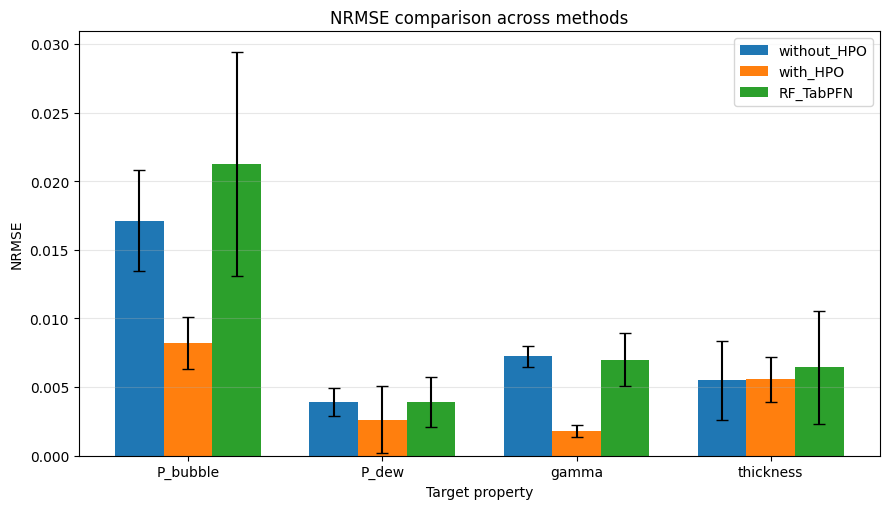

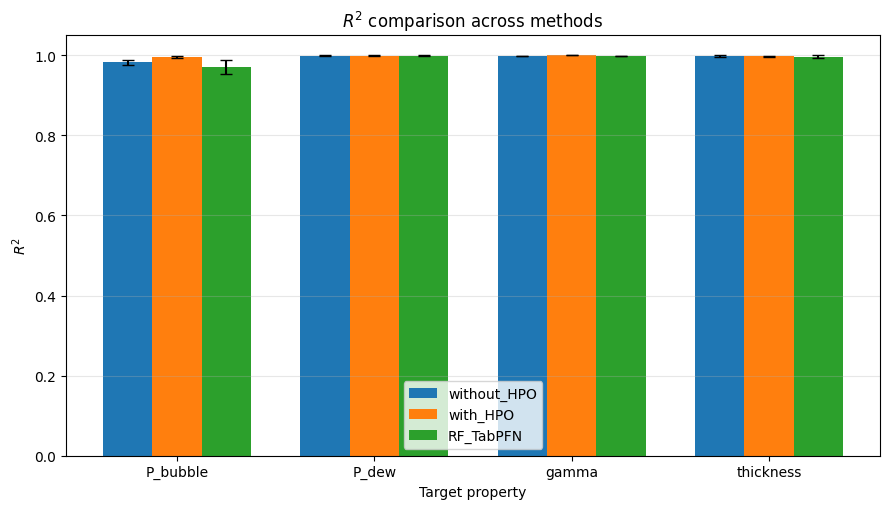

In [6]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    display(Markdown(f"Matplotlib could not be imported in this kernel: `{exc}`. Displaying the saved PNGs instead."))
    if DisplayImage is not None:
        for filename in ["comparisonCV_NRMSE.png", "comparisonCV_R2.png"]:
            path = OUT / filename
            if path.exists():
                display(DisplayImage(filename=str(path)))
else:
    def plot_grouped(metric, err_metric, ylabel, title, filename, ylim=None):
        x = range(len(PROPERTIES))
        width = 0.25
        fig, ax = plt.subplots(figsize=(9, 5.2))
        for i, method in enumerate(METHODS):
            values = [
                next(row[metric] for row in rows if row["property"] == prop and row["method"] == method)
                for prop in PROPERTIES
            ]
            errors = [
                next(row[err_metric] for row in rows if row["property"] == prop and row["method"] == method)
                for prop in PROPERTIES
            ]
            positions = [pos + (i - 1) * width for pos in x]
            ax.bar(
                positions,
                values,
                width,
                yerr=errors,
                capsize=4,
                ecolor="black",
                label=method,
                color=METHOD_COLORS[method],
            )
        ax.set_title(title)
        ax.set_xlabel("Target property")
        ax.set_ylabel(ylabel)
        ax.set_xticks(list(x))
        ax.set_xticklabels([DISPLAY_LABELS[prop] for prop in PROPERTIES])
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(axis="y", alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUT / filename, dpi=300, bbox_inches="tight")
        return fig, ax

    plot_grouped("cv_nrmse_mean", "cv_nrmse_std", "NRMSE", "NRMSE comparison across methods", "comparisonCV_NRMSE.png")
    plot_grouped("cv_r2_mean", "cv_r2_std", r"$R^2$", r"$R^2$ comparison across methods", "comparisonCV_R2.png", ylim=(0, 1.05))
